# 02 — Distributions & Outliers

**Goal:** Understand the shape of every numerical feature.

**Questions we answer here:**
- Are features normally distributed or skewed?
- Which columns have outliers?
- What is the typical range of each feature?

**Input:** `data/raw/consumer_shopping_2026.csv`
**Output:** charts saved to `docs/`

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../data/raw/Consumer_Shopping_Trends_2026.csv')
sns.set_theme(style='whitegrid')
print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Data loaded: 11,789 rows × 25 columns


In [14]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns ({len(num_cols)}):")
print(num_cols)
print(f"\nCategorical columns ({len(cat_cols)}):")
print(cat_cols)

Numerical columns (22):
['age', 'monthly_income', 'daily_internet_hours', 'smartphone_usage_years', 'social_media_hours', 'online_payment_trust_score', 'tech_savvy_score', 'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend', 'avg_store_spend', 'discount_sensitivity', 'return_frequency', 'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance', 'product_availability_online', 'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score', 'environmental_awareness', 'time_pressure_level']

Categorical columns (3):
['gender', 'city_tier', 'shopping_preference']


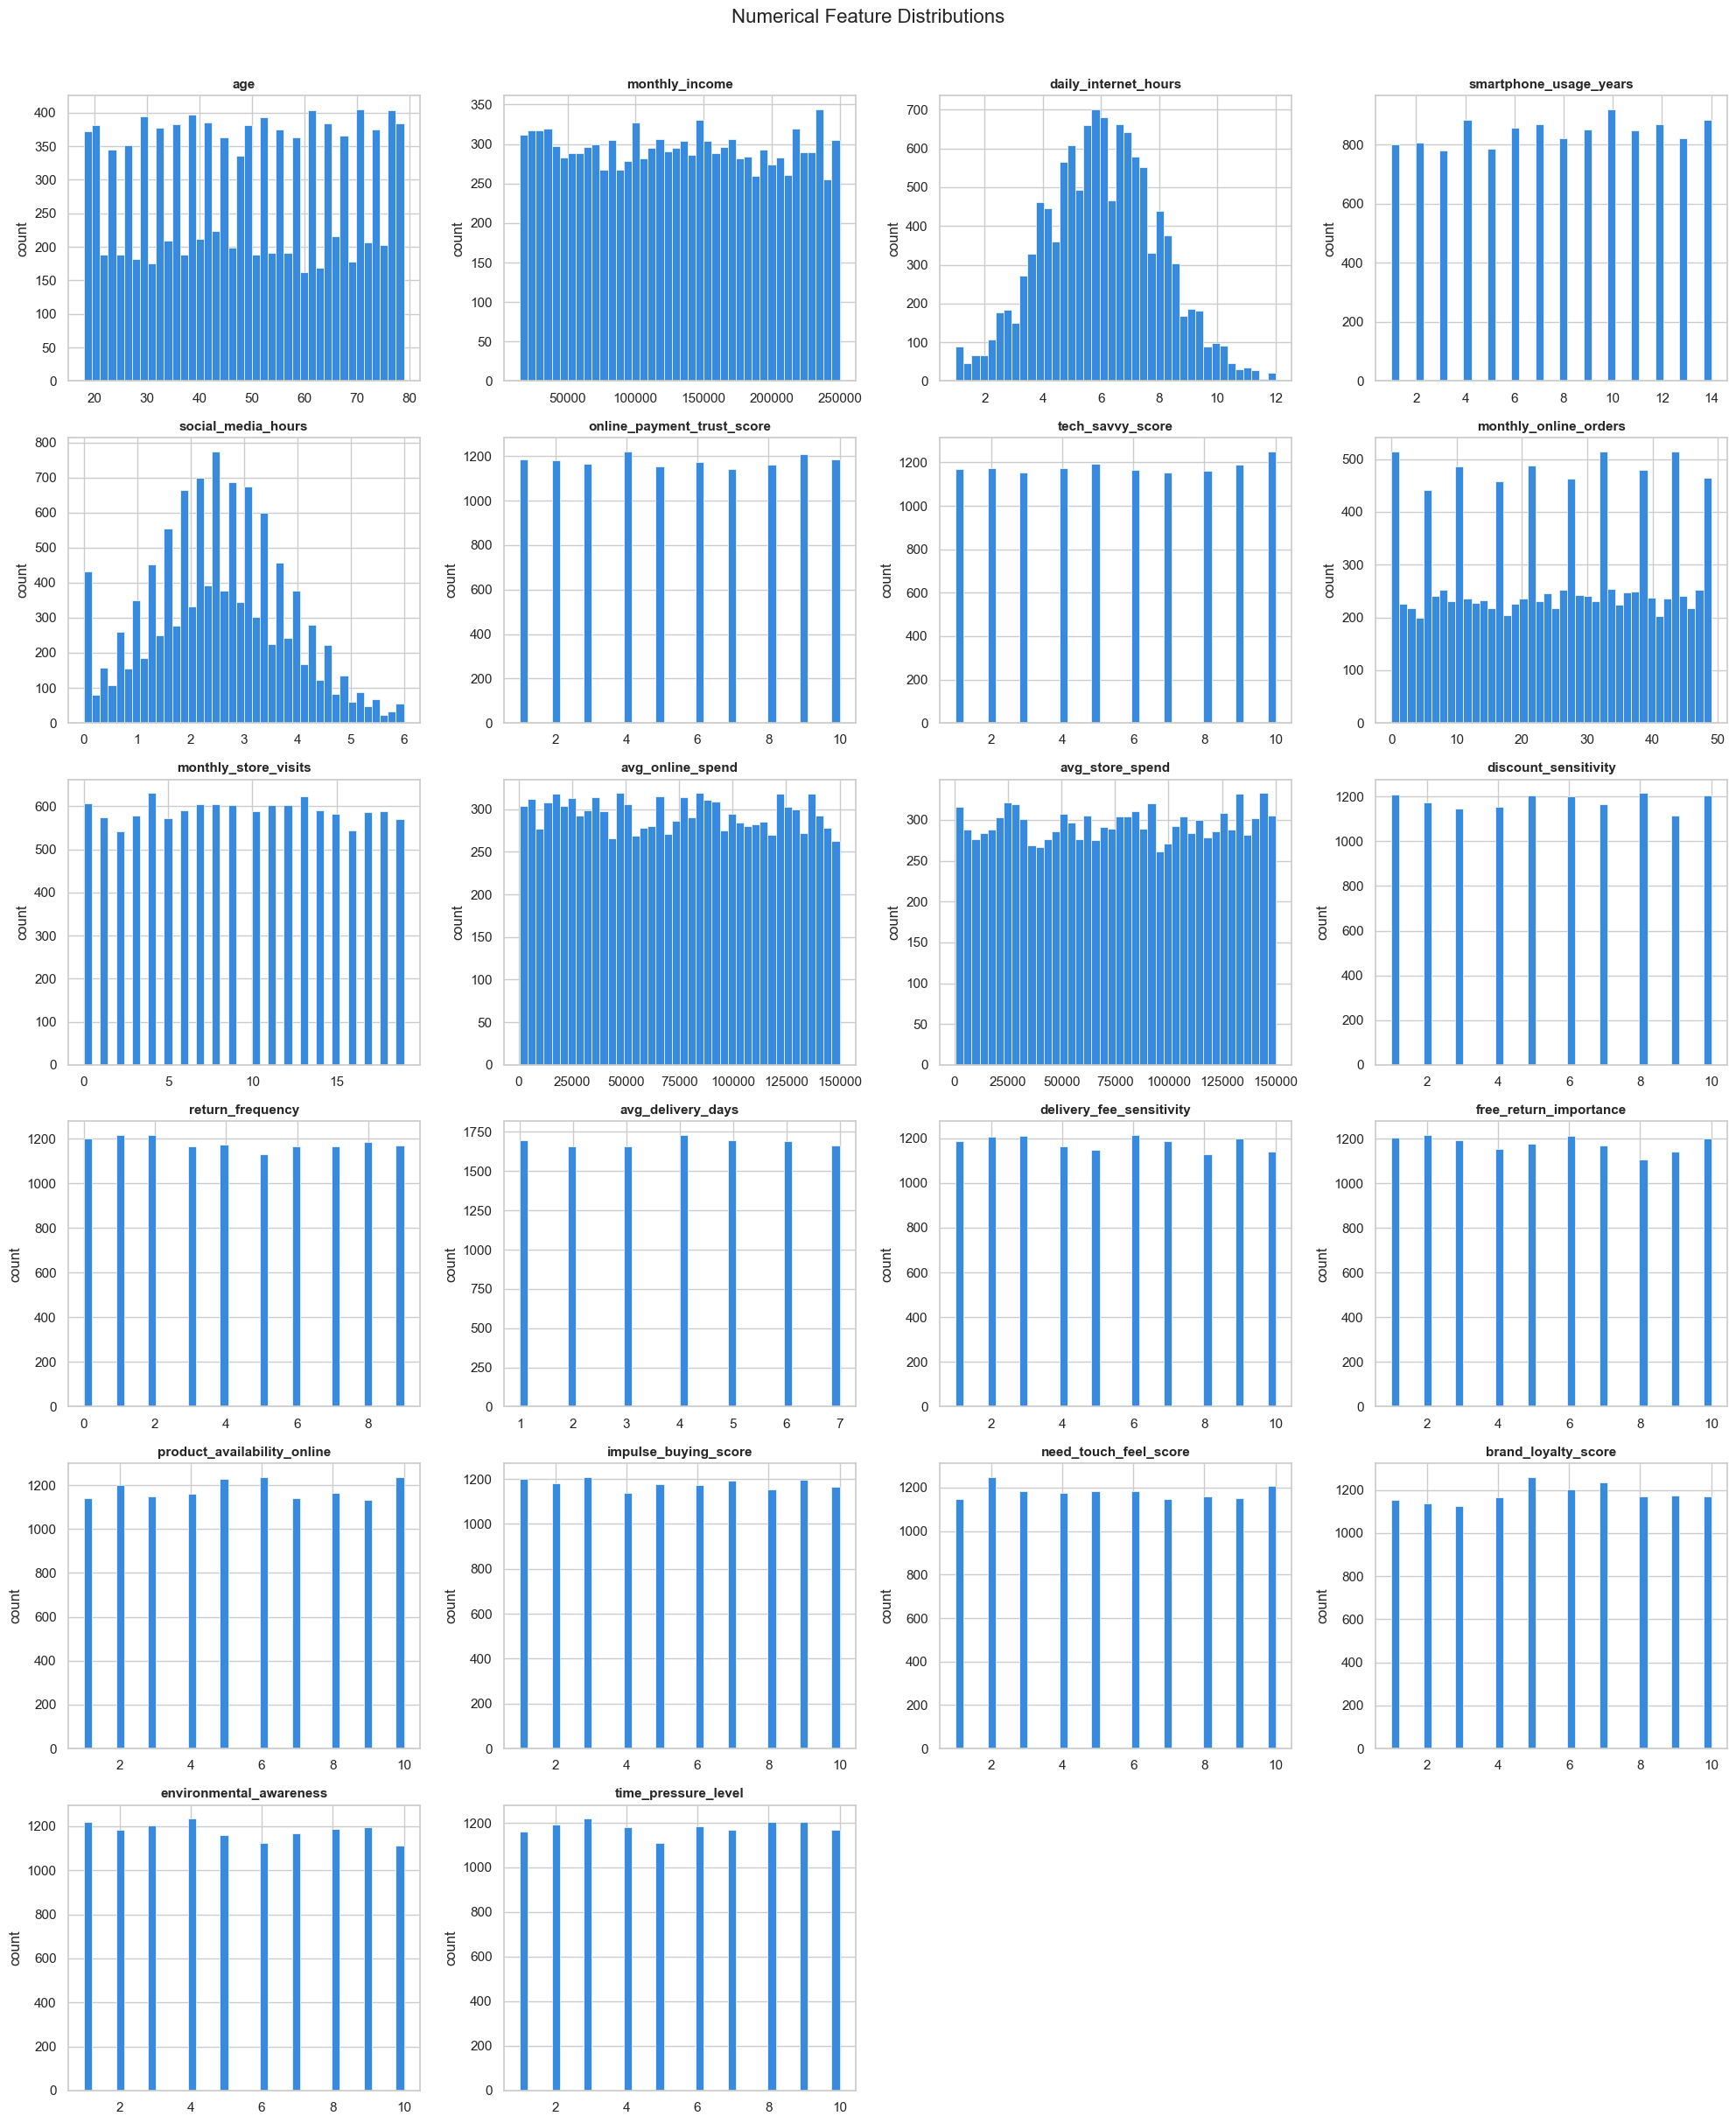

In [15]:
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='#378ADD', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('../../docs/distributions_all.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Cell 3 — Distribution Analysis

### Findings by group

**Continuous uniform features** (flat distribution across full range):
`age`, `monthly_income`, `avg_online_spend`, `avg_store_spend`,
`smartphone_usage_years`, `monthly_store_visits`, `avg_delivery_days`

**Score features — perfectly uniform** (each value 1–10 equally represented):
`online_payment_trust_score`, `tech_savvy_score`, `discount_sensitivity`,
`return_frequency`, `delivery_fee_sensitivity`, `free_return_importance`,
`product_availability_online`, `impulse_buying_score`, `need_touch_feel_score`,
`brand_loyalty_score`, `environmental_awareness`, `time_pressure_level`

**Near-normal features:**
`daily_internet_hours` — bell curve peaking at 6–7 hours
`social_media_hours` — slight right skew, peaks at 2–3 hours

### Key insight
The uniform distribution across almost all features confirms this is a
**simulated dataset.** Real-world consumer data would show:
- Right-skewed income (most people earn less, few earn a lot)
- Right-skewed online orders (most people order rarely)
- Normal-ish age distribution peaking at working age

### Impact on modeling
- No log transformations needed — no heavy skew to correct
- Score features will need **normalization** (min-max or standard scaling)
  so they're on the same scale as other features
- No outlier removal needed — uniform distribution has no extreme tails

In [16]:
skewness = df[num_cols].skew().round(3).sort_values(ascending=False)
print("Skewness scores (> 1 or < -1 needs attention):")
print(skewness)

Skewness scores (> 1 or < -1 needs attention):
social_media_hours             0.128
daily_internet_hours           0.038
free_return_importance         0.023
environmental_awareness        0.019
need_touch_feel_score          0.019
return_frequency               0.017
avg_online_spend               0.014
delivery_fee_sensitivity       0.012
monthly_income                 0.011
online_payment_trust_score     0.005
impulse_buying_score           0.003
product_availability_online    0.003
monthly_store_visits           0.001
time_pressure_level           -0.002
discount_sensitivity          -0.004
age                           -0.005
tech_savvy_score              -0.006
avg_delivery_days             -0.007
avg_store_spend               -0.007
brand_loyalty_score           -0.020
monthly_online_orders         -0.027
smartphone_usage_years        -0.030
dtype: float64


## 📊 Cell 4 — Skewness Scores

All 22 numerical features have skewness between -0.03 and +0.13.

No feature exceeds the ±1.0 threshold that would require transformation.

**Conclusion:** No log transformations or skewness corrections needed.
This is consistent with the simulated nature of the dataset.

In [17]:
outlier_report = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    outlier_report.append({
        'column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_outliers': n_outliers,
        'outlier_%': pct
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('outlier_%', ascending=False)
outlier_df[outlier_df['n_outliers'] > 0]

,column,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_%
2,daily_internet_hours,4.6,7.4,2.8,0.4,11.6,25,0.21




Only 1 column flagged: `daily_internet_hours`
- 25 rows (0.21%) fall outside the [0.4 — 11.6] hour range
- These represent extreme low/high internet users
- **Decision: keep them.** 0.21% is negligible and they represent
  real consumer profiles worth keeping in the model.

**All other 21 columns: zero outliers detected. ✅**

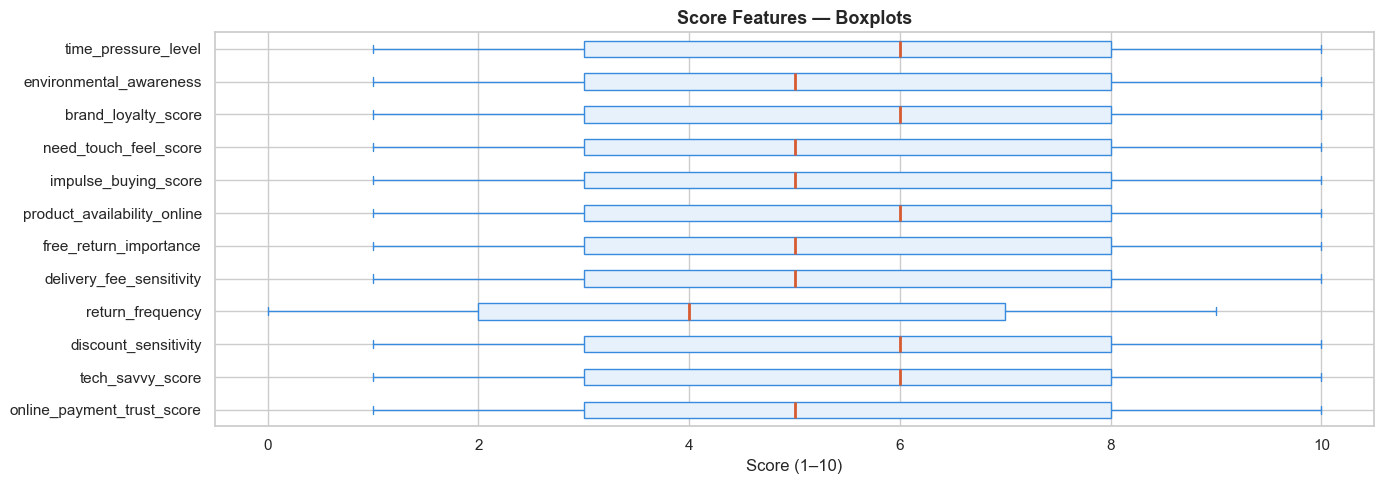

In [18]:
score_cols = [
    'online_payment_trust_score', 'tech_savvy_score',
    'discount_sensitivity', 'return_frequency',
    'delivery_fee_sensitivity', 'free_return_importance',
    'product_availability_online', 'impulse_buying_score',
    'need_touch_feel_score', 'brand_loyalty_score',
    'environmental_awareness', 'time_pressure_level'
]

fig, ax = plt.subplots(figsize=(14, 5))

df[score_cols].boxplot(ax=ax, vert=False, patch_artist=True,
    boxprops=dict(facecolor='#E6F1FB', color='#378ADD'),
    medianprops=dict(color='#D85A30', linewidth=2),
    whiskerprops=dict(color='#378ADD'),
    capprops=dict(color='#378ADD'))

ax.set_title('Score Features — Boxplots', fontsize=13, fontweight='bold')
ax.set_xlabel('Score (1–10)')
plt.tight_layout()
plt.savefig('../../docs/boxplots_scores.png', dpi=150, bbox_inches='tight')
plt.show()



All 12 score features (1–10 scale) show identical distribution:
- Box spans Q1=3 to Q3=8 (middle 50% of customers)
- Median sits at 5–6 for all features
- Whiskers reach the full 1–10 range
- Zero outliers confirmed visually

**Notable:** `return_frequency` has a slightly narrower range
(whisker stops at 9), suggesting fewer extreme returners.

**Key takeaway for the client:**
No psychological or behavioral score dominates the dataset.
Customers are genuinely diverse across all measured dimensions —
this makes segmentation meaningful and modeling more challenging.

In [19]:
summary = df.groupby('shopping_preference')[num_cols].mean().round(2).T
summary['online_vs_store_diff'] = (summary['Online'] - summary['Store']).round(2)
summary = summary.sort_values('online_vs_store_diff', ascending=False)
summary

shopping_preference,Hybrid,Online,Store,online_vs_store_diff
avg_online_spend,74304.44,76428.96,74348.82,2080.14
monthly_online_orders,25.38,28.31,24.24,4.07
tech_savvy_score,5.80,6.58,5.40,1.18
age,47.87,49.79,48.64,1.15
online_payment_trust_score,5.52,5.98,5.44,0.54
daily_internet_hours,6.18,6.34,5.97,0.37
product_availability_online,5.54,5.79,5.49,0.30
delivery_fee_sensitivity,5.39,5.53,5.46,0.07
avg_delivery_days,3.93,4.06,4.00,0.06
time_pressure_level,5.46,5.56,5.50,0.06


## 📊 Cell 7 — Mean Comparison by Shopping Preference

### Top drivers of ONLINE shopping preference
| Feature | Online | Store | Difference |
|---|---|---|---|
| avg_online_spend | 76,429 | 74,349 | +2,080 |
| monthly_online_orders | 28.31 | 24.24 | +4.07 |
| tech_savvy_score | 6.58 | 5.40 | +1.18 |
| online_payment_trust_score | 5.98 | 5.44 | +0.54 |

### Top barriers to ONLINE shopping (drivers of STORE preference)
| Feature | Online | Store | Difference |
|---|---|---|---|
| avg_store_spend | 11,191 | 85,103 | -73,912 |
| monthly_store_visits | 8.28 | 9.63 | -1.35 |
| need_touch_feel_score | 4.30 | 5.62 | -1.32 |

### Key business insights
1. **Tech savviness is the #1 psychological driver** of online preference
2. **Need to touch/feel products is the #1 barrier** to online adoption
3. **Online shoppers are not younger** — age difference is minimal (+1.15)
   This challenges the common assumption that online = young customers
4. **Hybrid customers are perfectly balanced** across all metrics —
   they represent the most flexible and potentially most valuable segment
5. **Income is not a strong predictor** — difference of only 1,505/month
   Online shopping is not purely an income-driven behavior

### Impact on modeling
These 5 features will likely be the most important in our classifier:
`tech_savvy_score`, `need_touch_feel_score`, `avg_store_spend`,
`monthly_online_orders`, `online_payment_trust_score`